Loading local boundaries...

--- STEP 1: PROVINCES ---
Available: 1, 2, 3 (Bagmati), 4 (Gandaki), 5, 6 (Karnali), 7 (Sudur Pashchim)


Select Province Number (1-7):  3



--- STEP 2: DISTRICTS IN Bagmati ---
1. BHAKTAPUR
2. CHITAWAN
3. DHADING
4. DOLAKHA
5. KABHREPALANCHOK
6. KATHMANDU
7. LALITPUR
8. MAKAWANPUR
9. NUWAKOT
10. RAMECHHAP
11. RASUWA
12. SINDHULI
13. SINDHUPALCHOK


Select District Number:  8



--- STEP 3: MUNICIPALITIES IN MAKAWANPUR ---
1. Bagmati
2. Bakaiya
3. Bhimphedi
4. Chitawan National Park
5. Hetauda
6. Indrasarowar
7. Kailash
8. Makawanpurgadhi
9. Manahari
10. Parsa Wildlife Reserve
11. Raksirang
12. Thaha


Select Municipality Number:  5



Dividing Hetauda into 5000 chunks...
Fetching real altitude data for 5000 points...
API Error 504. Using fallback simulation.
Data saved to: Hetauda_data.csv
Generating 3D Visualization...
Map saved to: Hetauda_3d_map.png


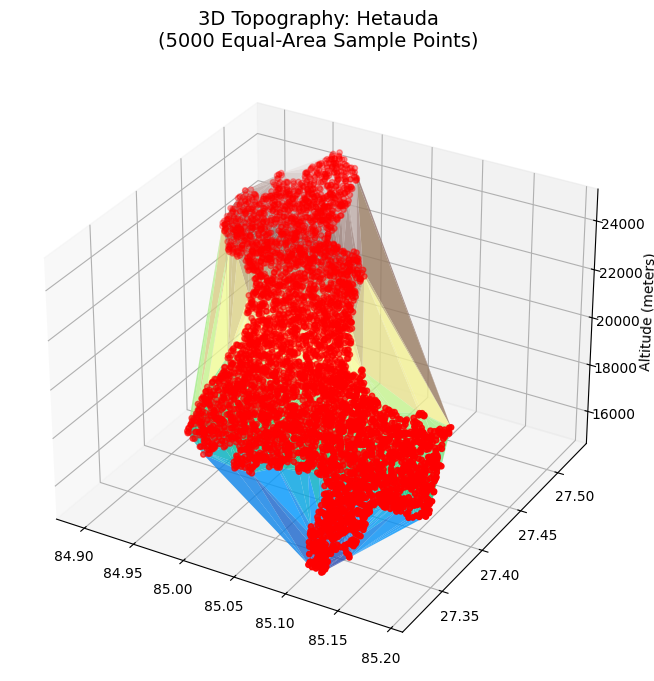

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from shapely.geometry import Point
import json
import requests

# ==========================================
# CONFIGURATION
# ==========================================
FILE_PATH = 'localboundries.json'
ch = 5000  # THE DIVIDING FACTOR: Change this to increase/decrease resolution

# Mapping user numbers (1-7) to the labels in your GeoJSON
PROVINCE_MAP = {
    "1": "1",
    "2": "2",
    "3": "Bagmati",
    "4": "Gandaki",
    "5": "5",
    "6": "Karnali",
    "7": "Sudur Pashchim"
}

def get_real_altitudes(coords):
    """Fetches real elevation data from Open-Elevation API."""
    url = "https://api.open-elevation.com/api/v1/lookup"
    locations = [{"latitude": lat, "longitude": lon} for lon, lat in coords]
    payload = {"locations": locations}
    
    try:
        print(f"Fetching real altitude data for {len(coords)} points...")
        response = requests.post(url, json=payload, timeout=30)
        if response.status_code == 200:
            return [res['elevation'] for res in response.json()['results']]
        else:
            print(f"API Error {response.status_code}. Using fallback simulation.")
            return None
    except Exception as e:
        print(f"Connection failed: {e}. Using fallback simulation.")
        return None

def main():
    # 1. LOAD GEODATA
    print("Loading local boundaries...")
    with open(FILE_PATH, 'r') as f:
        data = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(data['features'])

    # 2. HIERARCHICAL SELECTION
    # Province Selection
    print("\n--- STEP 1: PROVINCES ---")
    print("Available: 1, 2, 3 (Bagmati), 4 (Gandaki), 5, 6 (Karnali), 7 (Sudur Pashchim)")
    p_num = input("Select Province Number (1-7): ").strip()
    if p_num not in PROVINCE_MAP:
        print("Invalid Selection."); return
    
    p_name = PROVINCE_MAP[p_num]
    prov_gdf = gdf[gdf['Province'] == p_name]

    # District Selection
    print(f"\n--- STEP 2: DISTRICTS IN {p_name} ---")
    districts = sorted(prov_gdf['DISTRICT'].unique())
    for i, d in enumerate(districts, 1):
        print(f"{i}. {d}")
    d_idx = int(input("Select District Number: ")) - 1
    selected_dist = districts[d_idx]
    dist_gdf = prov_gdf[prov_gdf['DISTRICT'] == selected_dist]

    # Municipality Selection
    print(f"\n--- STEP 3: MUNICIPALITIES IN {selected_dist} ---")
    munis = sorted(dist_gdf['GaPa_NaPa'].unique())
    for i, m in enumerate(munis, 1):
        print(f"{i}. {m}")
    m_idx = int(input("Select Municipality Number: ")) - 1
    selected_muni = munis[m_idx]
    muni_gdf = dist_gdf[dist_gdf['GaPa_NaPa'] == selected_muni]

    # 3. SPATIAL CHUNKING (EQUAL AREA)
    print(f"\nDividing {selected_muni} into {ch} chunks...")
    poly = muni_gdf.geometry.iloc[0]
    minx, miny, maxx, maxy = poly.bounds
    
    # Generate random points inside the shape
    points = []
    while len(points) < 5000:
        p = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if poly.contains(p):
            points.append([p.x, p.y])
    
    # Use K-Means to find 100 center points (the chunks)
    kmeans = KMeans(n_clusters=ch, n_init=10, random_state=42)
    kmeans.fit(points)
    centers = kmeans.cluster_centers_

    # 4. GET ALTITUDE & SAVE DATA
    altitudes = get_real_altitudes(centers)
    if altitudes is None: # Fallback simulation if API is down
        altitudes = [1000 + (c[1] - 27) * 45000 for c in centers]

    df = pd.DataFrame({
        'Chunk_ID': range(1, ch + 1),
        'Longitude': centers[:, 0],
        'Latitude': centers[:, 1],
        'Altitude_m': altitudes
    })

    # Save CSV File
    csv_name = f"{selected_muni.replace(' ', '_')}_data.csv"
    df.to_csv(csv_name, index=False)
    print(f"Data saved to: {csv_name}")

    # 5. GENERATE 3D MAP
    print("Generating 3D Visualization...")
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Surface mesh
    ax.plot_trisurf(df['Longitude'], df['Latitude'], df['Altitude_m'], 
                    cmap='terrain', edgecolor='none', alpha=0.8)
    
    # Selected coordinates
    ax.scatter(df['Longitude'], df['Latitude'], df['Altitude_m'], 
               color='red', s=15, label='Sampled Chunks')

    ax.set_title(f"3D Topography: {selected_muni}\n({ch} Equal-Area Sample Points)", fontsize=14)
    ax.set_zlabel('Altitude (meters)')
    
    img_name = f"{selected_muni.replace(' ', '_')}_3d_map.png"
    plt.savefig(img_name)
    print(f"Map saved to: {img_name}")
    plt.show()

if __name__ == "__main__":
    main()

Loading local boundaries...

--- STEP 1: PROVINCES ---
Available: 1, 2, 3 (Bagmati), 4 (Gandaki), 5, 6 (Karnali), 7 (Sudur Pashchim)


Select Province Number (1-7):  3



--- STEP 2: DISTRICTS IN Bagmati ---
  1. BHAKTAPUR
  2. CHITAWAN
  3. DHADING
  4. DOLAKHA
  5. KABHREPALANCHOK
  6. KATHMANDU
  7. LALITPUR
  8. MAKAWANPUR
  9. NUWAKOT
  10. RAMECHHAP
  11. RASUWA
  12. SINDHULI
  13. SINDHUPALCHOK


Select District Number:  8



--- STEP 3: MUNICIPALITIES IN MAKAWANPUR ---
  1. Bagmati
  2. Bakaiya
  3. Bhimphedi
  4. Chitawan National Park
  5. Hetauda
  6. Indrasarowar
  7. Kailash
  8. Makawanpurgadhi
  9. Manahari
  10. Parsa Wildlife Reserve
  11. Raksirang
  12. Thaha


Select Municipality Number:  9



Generating sample points inside Manahari...
  5000 valid points generated inside polygon.
  Clustering into 100 spatial chunks...

Running Monte Carlo elevation sampling (5 draws per chunk)...
  Total API calls: ~500 points across 100 batches

  Chunk 1/100 (66 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 2/100 (51 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 3/100 (56 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 4/100 (36 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 5/100 (50 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 6/100 (54 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 7/100 (54 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 8/100 (50 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 9/100 (39 points in cluster)...
  Fetching elevation for 5 points...
  Chunk 10/100 (33 points in cluster)...
  Fetching elevation 

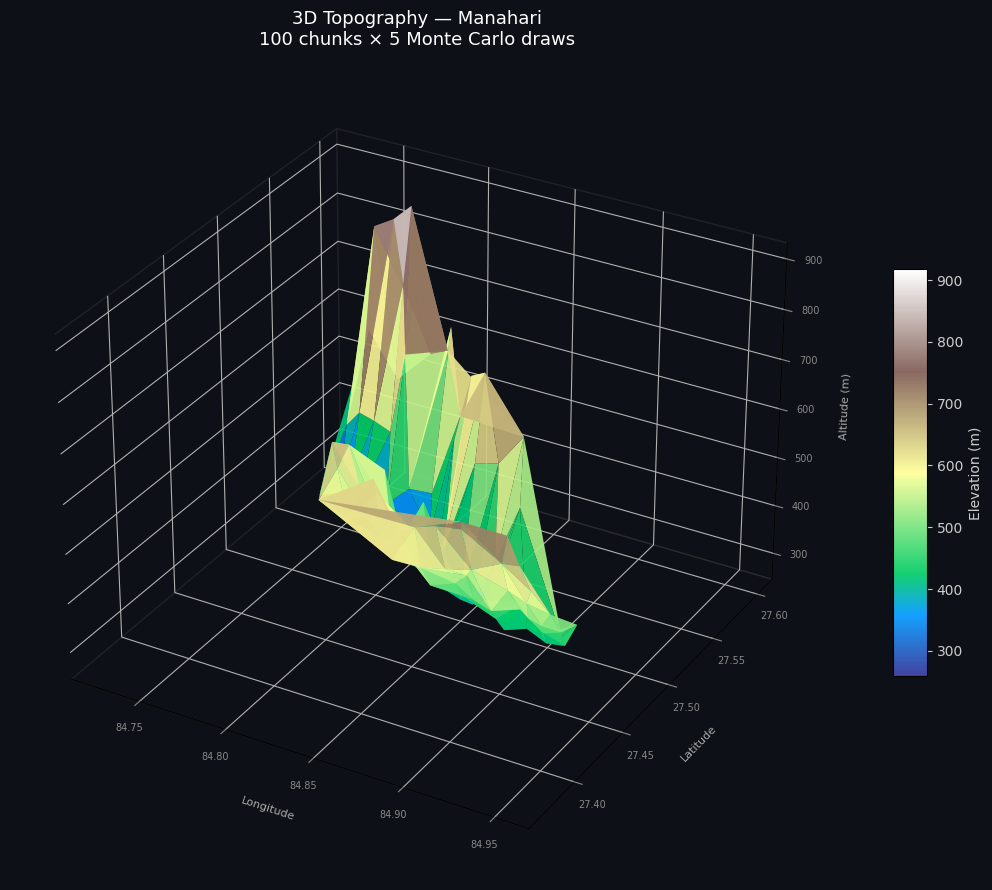


  Municipality : Manahari
  Chunks       : 100
  MC draws/chunk: 5
  Min elevation: 259 m
  Max elevation: 918 m
  Mean elevation: 527 m



In [8]:
#Claudeai
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans
from shapely.geometry import Point
import json
import requests
import random

# ==========================================
# CONFIGURATION
# ==========================================
FILE_PATH = 'localboundries.json'
ch = 100          # Number of spatial chunks (final sample points)
MONTE_CARLO_N = 5  # How many random draws per chunk for elevation averaging

PROVINCE_MAP = {
    "1": "1",
    "2": "2",
    "3": "Bagmati",
    "4": "Gandaki",
    "5": "5",
    "6": "Karnali",
    "7": "Sudur Pashchim"
}


# ==========================================
# ELEVATION FETCHING
# ==========================================
def get_real_altitudes(coords):
    """
    Fetches real elevation data from Open-Elevation API.
    coords: list of (lon, lat) tuples
    Returns: list of elevations in meters, or None on failure.
    """
    url = "https://api.open-elevation.com/api/v1/lookup"
    locations = [{"latitude": lat, "longitude": lon} for lon, lat in coords]
    payload = {"locations": locations}

    try:
        print(f"  Fetching elevation for {len(coords)} points...")
        response = requests.post(url, json=payload, timeout=60)
        if response.status_code == 200:
            return [res['elevation'] for res in response.json()['results']]
        else:
            print(f"  API Error {response.status_code}. Using fallback.")
            return None
    except Exception as e:
        print(f"  Connection failed: {e}. Using fallback.")
        return None


def fallback_elevation(lon, lat):
    """Rough elevation simulation based on Nepal's north-south gradient."""
    return 1000 + (lat - 27) * 45000 + random.uniform(-200, 200)


# ==========================================
# MONTE CARLO ELEVATION ESTIMATOR
# ==========================================
def monte_carlo_elevation(chunk_points, N=5):
    """
    For a single chunk (list of [lon, lat] points):
      - Randomly sample N points from within the chunk
      - Fetch their real elevations
      - Return the mean elevation and the coordinate of the median-elevation pick

    This avoids the centroid-outside-polygon problem and gives a statistically
    more robust elevation estimate than a single sample.
    """
    # Draw N random picks from the chunk's points
    picks = random.choices(chunk_points, k=N)  # with replacement; fine for small chunks

    # Fetch elevations for all N picks in one API call (batched)
    elevations = get_real_altitudes(picks)

    if elevations is None:
        # Fallback: simulate for each pick
        elevations = [fallback_elevation(p[0], p[1]) for p in picks]

    mean_elev = float(np.mean(elevations))

    # Use the pick closest to the mean elevation as the representative coordinate
    diffs = [abs(e - mean_elev) for e in elevations]
    best_pick = picks[int(np.argmin(diffs))]

    return best_pick[0], best_pick[1], mean_elev  # lon, lat, avg_elevation


# ==========================================
# MAIN
# ==========================================
def main():
    # ---- 1. LOAD GEODATA ----
    print("Loading local boundaries...")
    with open(FILE_PATH, 'r') as f:
        data = json.load(f)
    gdf = gpd.GeoDataFrame.from_features(data['features'])

    # ---- 2. HIERARCHICAL SELECTION ----
    print("\n--- STEP 1: PROVINCES ---")
    print("Available: 1, 2, 3 (Bagmati), 4 (Gandaki), 5, 6 (Karnali), 7 (Sudur Pashchim)")
    p_num = input("Select Province Number (1-7): ").strip()
    if p_num not in PROVINCE_MAP:
        print("Invalid selection."); return
    p_name = PROVINCE_MAP[p_num]
    prov_gdf = gdf[gdf['Province'] == p_name]

    print(f"\n--- STEP 2: DISTRICTS IN {p_name} ---")
    districts = sorted(prov_gdf['DISTRICT'].unique())
    for i, d in enumerate(districts, 1):
        print(f"  {i}. {d}")
    d_idx = int(input("Select District Number: ")) - 1
    selected_dist = districts[d_idx]
    dist_gdf = prov_gdf[prov_gdf['DISTRICT'] == selected_dist]

    print(f"\n--- STEP 3: MUNICIPALITIES IN {selected_dist} ---")
    munis = sorted(dist_gdf['GaPa_NaPa'].unique())
    for i, m in enumerate(munis, 1):
        print(f"  {i}. {m}")
    m_idx = int(input("Select Municipality Number: ")) - 1
    selected_muni = munis[m_idx]
    muni_gdf = dist_gdf[dist_gdf['GaPa_NaPa'] == selected_muni]

    # ---- 3. GENERATE RANDOM POINTS INSIDE POLYGON ----
    print(f"\nGenerating sample points inside {selected_muni}...")
    poly = muni_gdf.geometry.iloc[0]
    minx, miny, maxx, maxy = poly.bounds

    points = []
    attempts = 0
    while len(points) < 5000:
        p = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
        if poly.contains(p):
            points.append([p.x, p.y])
        attempts += 1
        if attempts > 200000:
            print("Warning: Could not fill 5000 points. Using what we have.")
            break

    print(f"  {len(points)} valid points generated inside polygon.")

    # ---- 4. K-MEANS SPATIAL CHUNKING ----
    print(f"  Clustering into {ch} spatial chunks...")
    kmeans = KMeans(n_clusters=ch, n_init=10, random_state=42)
    kmeans.fit(points)
    labels = kmeans.labels_

    # Group points by cluster
    chunks = {}
    for i, label in enumerate(labels):
        chunks.setdefault(label, []).append(points[i])

    # ---- 5. MONTE CARLO ELEVATION SAMPLING ----
    print(f"\nRunning Monte Carlo elevation sampling ({MONTE_CARLO_N} draws per chunk)...")
    print(f"  Total API calls: ~{ch * MONTE_CARLO_N} points across {ch} batches\n")

    results = []
    for cluster_id in range(ch):
        chunk_pts = chunks[cluster_id]
        print(f"  Chunk {cluster_id + 1}/{ch} ({len(chunk_pts)} points in cluster)...")
        lon, lat, avg_elev = monte_carlo_elevation(chunk_pts, N=MONTE_CARLO_N)
        results.append({
            'Chunk_ID': cluster_id + 1,
            'Longitude': lon,
            'Latitude': lat,
            'Altitude_m': avg_elev,
            'MC_Draws': MONTE_CARLO_N
        })

    df = pd.DataFrame(results)

    # ---- 6. SAVE CSV ----
    csv_name = f"{selected_muni.replace(' ', '_')}_montecarlo_data.csv"
    df.to_csv(csv_name, index=False)
    print(f"\nData saved to: {csv_name}")

    # ---- 7. 3D TERRAIN VISUALIZATION ----
    print("Generating 3D terrain visualization...")

    fig = plt.figure(figsize=(14, 9), facecolor='#0d1117')
    ax = fig.add_subplot(111, projection='3d', facecolor='#0d1117')

    lons = df['Longitude'].values
    lats = df['Latitude'].values
    alts = df['Altitude_m'].values

    # Normalize elevations for coloring
    norm = mcolors.Normalize(vmin=alts.min(), vmax=alts.max())
    cmap = plt.cm.terrain

    # Triangulated surface — NO scatter dots
    surf = ax.plot_trisurf(
        lons, lats, alts,
        cmap=cmap,
        norm=norm,
        edgecolor='none',
        alpha=0.92,
        linewidth=0
    )

    # Colorbar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12, pad=0.05)
    cbar.set_label('Elevation (m)', color='#cccccc', fontsize=10)
    cbar.ax.yaxis.set_tick_params(color='#cccccc')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#cccccc')

    # Axis labels and title
    ax.set_title(
        f"3D Topography — {selected_muni}\n"
        f"{ch} chunks × {MONTE_CARLO_N} Monte Carlo draws",
        color='white', fontsize=13, pad=15
    )
    ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=8, labelpad=8)
    ax.set_ylabel('Latitude', color='#aaaaaa', fontsize=8, labelpad=8)
    ax.set_zlabel('Altitude (m)', color='#aaaaaa', fontsize=8, labelpad=8)

    # Dark pane colors
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#333333')
    ax.yaxis.pane.set_edgecolor('#333333')
    ax.zaxis.pane.set_edgecolor('#333333')
    ax.tick_params(colors='#888888', labelsize=7)
    ax.grid(True, color='#222222', linewidth=0.4)

    plt.tight_layout()

    img_name = f"{selected_muni.replace(' ', '_')}_3d_terrain.png"
    plt.savefig(img_name, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    print(f"Map saved to: {img_name}")
    plt.show()

    # ---- 8. SUMMARY ----
    print(f"\n{'='*50}")
    print(f"  Municipality : {selected_muni}")
    print(f"  Chunks       : {ch}")
    print(f"  MC draws/chunk: {MONTE_CARLO_N}")
    print(f"  Min elevation: {alts.min():.0f} m")
    print(f"  Max elevation: {alts.max():.0f} m")
    print(f"  Mean elevation: {alts.mean():.0f} m")
    print(f"{'='*50}\n")


if __name__ == "__main__":
    main()